In [1]:
#setup
from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/Proyek_CRM_KELOMPOK')
sys.path.append(str(PROJECT_DIR))

from project_config import PROCESSED_DIR, OUTPUT_DIR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

Mounted at /content/drive


In [2]:
# Load dataset modeling dan split index
modeling_df = pd.read_csv(PROCESSED_DIR / 'modeling_dataset.csv')
split_index = pd.read_csv(OUTPUT_DIR / 'train_test_index.csv')

print(modeling_df.shape)
modeling_df.head()

(286, 54)


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,...,Influence of rating,Less Delivery time,High Quality of package,Number of calls,Politeness,Freshness,Temperature,Good Taste,Good Quantity,churn_risk
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,...,Yes,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,0
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,...,Yes,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,0
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,...,Yes,Important,Very Important,Moderately Important,Very Important,Very Important,Important,Very Important,Moderately Important,0
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,...,Yes,Very Important,Important,Moderately Important,Very Important,Very Important,Very Important,Very Important,Important,0
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,...,Yes,Important,Important,Moderately Important,Important,Important,Important,Very Important,Very Important,0


In [3]:
#Pisahkan train test
train_idx = split_index[split_index['split'] == 'train']['index']
test_idx = split_index[split_index['split'] == 'test']['index']

train_df = modeling_df.loc[train_idx]
test_df = modeling_df.loc[test_idx]

X_train = train_df.drop(columns=['churn_risk'])
y_train = train_df['churn_risk']

X_test = test_df.drop(columns=['churn_risk'])
y_test = test_df['churn_risk']

print(X_train.shape, X_test.shape)

(228, 53) (58, 53)


In [4]:
# membuat preprocessing pipeline
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [5]:
# mendefinisikan model yang digunakan
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=9
    )
}

In [6]:
# Train dan evaluasi
model_results = []
trained_models = {}

for name, estimator in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps['model'], 'predict_proba'):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    model_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc
    })

    trained_models[name] = pipeline

model_comparison = pd.DataFrame(model_results).sort_values('f1_score', ascending=False)
model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.931034,1.00,0.692308,0.818182,0.955556
3,KNN,0.896552,1.00,0.538462,0.700000,0.935897
1,Decision Tree,0.741379,0.45,0.692308,0.545455,0.752991
0,Logistic Regression,0.775862,0.50,0.538462,0.518519,0.811966


In [7]:
# simpan perbandingan model
model_comparison_path = OUTPUT_DIR / 'model_comparison_result.csv'
model_comparison.to_csv(model_comparison_path, index=False)

print('Model comparison disimpan:', model_comparison_path)

Model comparison disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/model_comparison_result.csv


In [8]:
# random forest
best_model = trained_models['Random Forest']

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [9]:
# classification report
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=['Beli ulang', 'Risiko churn'],
    output_dict=True
)

classification_report_df = pd.DataFrame(report_dict).transpose()
classification_report_df

,precision,recall,f1-score,support
Beli ulang,0.918367,1.000000,0.957447,45.000000
Risiko churn,1.000000,0.692308,0.818182,13.000000
accuracy,0.931034,0.931034,0.931034,0.931034
macro avg,0.959184,0.846154,0.887814,58.000000
weighted avg,0.936664,0.931034,0.926232,58.000000


In [10]:
#simpan
report_path = OUTPUT_DIR / 'classification_report_random_forest.csv'
classification_report_df.to_csv(report_path)

print('Classification report disimpan:', report_path)

Classification report disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/classification_report_random_forest.csv


In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Aktual Beli ulang', 'Aktual Risiko churn'],
    columns=['Prediksi Beli ulang', 'Prediksi Risiko churn']
)

cm_df

,Prediksi Beli ulang,Prediksi Risiko churn
Aktual Beli ulang,45,0
Aktual Risiko churn,4,9


In [12]:
# simpan convusion
cm_path = OUTPUT_DIR / 'confusion_matrix_random_forest.csv'
cm_df.to_csv(cm_path)

print('Confusion matrix disimpan:', cm_path)

Confusion matrix disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/confusion_matrix_random_forest.csv


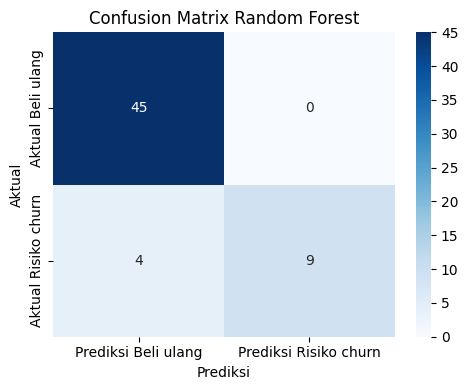

In [13]:
# Grafik confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()

chart_path = OUTPUT_DIR / '06_confusion_matrix_random_forest.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# simpan model
model_path = OUTPUT_DIR / 'best_random_forest_model.joblib'
joblib.dump(best_model, model_path)

print('Model disimpan:', model_path)

Model disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/best_random_forest_model.joblib
